# 05 — Hybrid CNN

**Prerequisites:** Run `03_feature_engineering.ipynb` first
Loads from `DATA_DIR`:
- `X_train/val/test_glove.npy` — padded integer sequences
- `glove_embedding_matrix.npy` — pretrained GloVe vectors (30000 × 100)
- `stylometric_train/val/test.csv` — 5 hand-crafted features per text
- `train.csv`, `val.csv`, `test.csv` — for labels and cross-dataset eval

**Baselines to beat (from file 04):**
| Model | Macro F1 | ROC-AUC |
|---|---|---|
| Logistic Regression | 0.9645 | 0.9943 |
| LinearSVC | 0.9637 | 0.9941 |
| Random Forest | 0.9415 | 0.9873 |
| Dummy baseline | 0.3441 | 0.5000 |

**Cross-dataset performance already achieved (file 04):**
| Dataset | Best F1 |
|---|---|
| HC3 | 0.9591 (LR) |
| DAIGT | 0.9633 (LR) |

## Architecture — Dual-Stream Hybrid CNN
```
Stream A (stylometric)           Stream B (GloVe embeddings)
  word_count                     Token sequence (200 tokens)
  char_count                           ↓
  avg_sentence_len  → Dense(64)  Embedding(30000, 100, frozen)
  punct_density        ReLU            ↓
  type_token_ratio                Conv1D(filters, kernel)
        ↓                               ↓
    64-dim vector              GlobalMaxPooling1D
                                        ↓
                                    64-dim vector
                  ↘              ↙
               Concatenate (128-dim)
                        ↓
                   Dropout(p)
                        ↓
                Dense(1, sigmoid)
                        ↓
               P(AI-generated)
```

## What this notebook does
| Step | Description |
|---|---|
| 0 | Imports & constants |
| 1 | Load artefacts from file 03 |
| 2 | Build PyTorch Dataset & DataLoader |
| 3 | Define Hybrid CNN architecture |
| 4 | Training loop with early stopping |
| 5 | Hyperparameter grid search |
| 6 | Evaluate best model on val + test |
| 7 | Visualisations |
| 8 | Cross-dataset generalisation test |
| 9 | Save best model |
| 10 | Final summary |

---

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import torch
print(torch.cuda.is_available())        # should print True
print(torch.cuda.get_device_name(0))    # should print something like Tesla T4

True
Tesla T4


## 0. Imports & Constants

In [5]:
# =============================================================================
# 05_hybrid_cnn.ipynb
# Hybrid CNN — Dual-Stream: Stylometric + GloVe Embeddings
# Detecting AI-Generated Text | MSc Data Science | Group Project
# =============================================================================

import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    RocCurveDisplay
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

# ── Reproducibility — must match all previous files ───────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# ── File paths — same DATA_DIR as files 01–04 ─────────────────────────────────
DATA_DIR   = "/content/drive/MyDrive/Team_project/project"
TRAIN_FILE = os.path.join(DATA_DIR, "train.csv")
VAL_FILE   = os.path.join(DATA_DIR, "val.csv")
TEST_FILE  = os.path.join(DATA_DIR, "test.csv")

# ── GloVe / embedding settings — must match file 03 ──────────────────────────
VOCAB_SIZE     = 30_000   # vocabulary built in file 03
EMBED_DIM      = 100      # glove.6B.100d
MAX_SEQ_LEN    = 200      # padding length from file 03
NUM_STYLE_FEAT = 5        # word_count, char_count, avg_sentence_len,
                          # punct_density, type_token_ratio

# ── KPI thresholds (from project_specifications.docx) ────────────────────────
KPI_MIN_F1     = 0.83
KPI_TARGET_F1  = 0.90
KPI_MIN_CROSS  = 0.75

# ── Baselines from file 04 (confirmed results) ────────────────────────────────
BEST_CLASSICAL_F1  = 0.9645   # Logistic Regression
BEST_CLASSICAL_AUC = 0.9943

# ── Training settings ─────────────────────────────────────────────────────────
BATCH_SIZE  = 64
MAX_EPOCHS  = 20
PATIENCE    = 3      # early stopping: stop if val F1 does not improve for 3 epochs

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("Constants defined.")
print(f"  DATA_DIR           : {DATA_DIR}")
print(f"  DEVICE             : {DEVICE}")
print(f"  VOCAB_SIZE         : {VOCAB_SIZE:,}")
print(f"  EMBED_DIM          : {EMBED_DIM}")
print(f"  MAX_SEQ_LEN        : {MAX_SEQ_LEN}")
print(f"  NUM_STYLE_FEAT     : {NUM_STYLE_FEAT}")
print(f"  Best classical F1  : {BEST_CLASSICAL_F1} (LR, file 04)")
print(f"  Train size         : 106,605 rows")
print(f"  Val / Test size    : 22,844 rows each")

Constants defined.
  DATA_DIR           : /content/drive/MyDrive/Team_project/project
  DEVICE             : cuda
  VOCAB_SIZE         : 30,000
  EMBED_DIM          : 100
  MAX_SEQ_LEN        : 200
  NUM_STYLE_FEAT     : 5
  Best classical F1  : 0.9645 (LR, file 04)
  Train size         : 106,605 rows
  Val / Test size    : 22,844 rows each


---
## 1. Load Artefacts from File 03

In [6]:
print("=" * 60)
print("STEP 1: Loading artefacts")
print("=" * 60)

# ── Guard: fail with clear message if file 03 not run ────────────────────────
required = [
    'X_train_glove.npy', 'X_val_glove.npy', 'X_test_glove.npy',
    'glove_embedding_matrix.npy',
    'stylometric_train.csv', 'stylometric_val.csv', 'stylometric_test.csv',
]
missing = [f for f in required
           if not os.path.exists(os.path.join(DATA_DIR, f))]
if missing:
    raise FileNotFoundError(
        "\n[ERROR] Missing artefacts from file 03:\n" +
        "\n".join(f"  {DATA_DIR}/{f}" for f in missing) +
        "\nPlease run 03_feature_engineering.ipynb first."
    )

# ── GloVe integer sequences ───────────────────────────────────────────────────
X_train_glove = np.load(os.path.join(DATA_DIR, 'X_train_glove.npy'))
X_val_glove   = np.load(os.path.join(DATA_DIR, 'X_val_glove.npy'))
X_test_glove  = np.load(os.path.join(DATA_DIR, 'X_test_glove.npy'))

# ── Pre-trained GloVe embedding matrix ────────────────────────────────────────
embedding_matrix = np.load(os.path.join(DATA_DIR, 'glove_embedding_matrix.npy'))

# ── Stylometric features ──────────────────────────────────────────────────────
STYLE_COLS = ['word_count', 'char_count', 'avg_sentence_len',
              'punct_density', 'type_token_ratio']

style_train_df = pd.read_csv(os.path.join(DATA_DIR, 'stylometric_train.csv'))
style_val_df   = pd.read_csv(os.path.join(DATA_DIR, 'stylometric_val.csv'))
style_test_df  = pd.read_csv(os.path.join(DATA_DIR, 'stylometric_test.csv'))

X_train_style = style_train_df[STYLE_COLS].values.astype(np.float32)
X_val_style   = style_val_df[STYLE_COLS].values.astype(np.float32)
X_test_style  = style_test_df[STYLE_COLS].values.astype(np.float32)

y_train = style_train_df['label'].values.astype(np.float32)
y_val   = style_val_df['label'].values.astype(np.float32)
y_test  = style_test_df['label'].values.astype(np.float32)

# ── Load CSVs for cross-dataset eval ──────────────────────────────────────────
train_df = pd.read_csv(TRAIN_FILE, encoding='utf-8-sig')
val_df   = pd.read_csv(VAL_FILE,   encoding='utf-8-sig')
test_df  = pd.read_csv(TEST_FILE,  encoding='utf-8-sig')

# ── Normalise stylometric features — fit on train only ────────────────────────
style_mean = X_train_style.mean(axis=0)
style_std  = X_train_style.std(axis=0) + 1e-8

X_train_style = (X_train_style - style_mean) / style_std
X_val_style   = (X_val_style   - style_mean) / style_std
X_test_style  = (X_test_style  - style_mean) / style_std

print(f"  GloVe sequences — Train : {X_train_glove.shape}")
print(f"  GloVe sequences — Val   : {X_val_glove.shape}")
print(f"  GloVe sequences — Test  : {X_test_glove.shape}")
print(f"  Embedding matrix        : {embedding_matrix.shape}")
print(f"  Stylometric — Train     : {X_train_style.shape}")
print(f"  Label dist  — Train     : {np.bincount(y_train.astype(int))}")
print(f"  Device                  : {DEVICE}")
print("\n  All artefacts loaded ✓")

STEP 1: Loading artefacts
  GloVe sequences — Train : (106605, 200)
  GloVe sequences — Val   : (22844, 200)
  GloVe sequences — Test  : (22844, 200)
  Embedding matrix        : (30000, 100)
  Stylometric — Train     : (106605, 5)
  Label dist  — Train     : [55923 50682]
  Device                  : cuda

  All artefacts loaded ✓


---
## 2. PyTorch Dataset & DataLoader

Wraps GloVe sequences, stylometric features, and labels into PyTorch
Dataset objects so they can be batched and shuffled during training.

In [7]:
class AITextDataset(Dataset):
    """
    PyTorch Dataset for the Hybrid CNN.

    Each sample contains three tensors:
        seq   : LongTensor (MAX_SEQ_LEN,)  — token integer indices for embedding
        style : FloatTensor (NUM_STYLE_FEAT,) — normalised stylometric features
        label : FloatTensor scalar — 0.0=Human, 1.0=AI
    """

    def __init__(self, sequences, style_feats, labels):
        self.sequences   = torch.tensor(sequences,   dtype=torch.long)
        self.style_feats = torch.tensor(style_feats, dtype=torch.float32)
        self.labels      = torch.tensor(labels,      dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sequences[idx], self.style_feats[idx], self.labels[idx]


train_dataset = AITextDataset(X_train_glove, X_train_style, y_train)
val_dataset   = AITextDataset(X_val_glove,   X_val_style,   y_val)
test_dataset  = AITextDataset(X_test_glove,  X_test_style,  y_test)

# shuffle=True on train only — val/test must remain deterministic
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0)

print(f"  Train batches : {len(train_loader):,}  ({len(train_dataset):,} samples)")
print(f"  Val batches   : {len(val_loader):,}   ({len(val_dataset):,} samples)")
print(f"  Test batches  : {len(test_loader):,}   ({len(test_dataset):,} samples)")
print(f"  Batch size    : {BATCH_SIZE}")
print("  Datasets and loaders ready ✓")

  Train batches : 1,666  (106,605 samples)
  Val batches   : 357   (22,844 samples)
  Test batches  : 357   (22,844 samples)
  Batch size    : 64
  Datasets and loaders ready ✓


---
## 3. Hybrid CNN Architecture

**Stream A — Stylometric branch**
5 normalised features → Linear(5→64) → ReLU → 64-dim vector

**Stream B — Embedding branch**
Sequence → Embedding(30000, 100, pretrained GloVe, frozen)
→ Conv1D(filters, kernel) → ReLU → GlobalMaxPool1D → Linear(filters→64) → ReLU → 64-dim vector

**Fusion**
Concatenate(128) → Dropout(p) → Linear(128→1) → Sigmoid → P(AI)

In [8]:
class HybridCNN(nn.Module):
    """
    Dual-stream Hybrid CNN for AI-generated text detection.

    Stream A processes hand-crafted stylometric features through a dense layer.
    Stream B processes GloVe-embedded token sequences through a 1D convolution.
    Both 64-dimensional outputs are concatenated and fed to a sigmoid head.

    Args:
        embedding_matrix  : numpy array (vocab_size, embed_dim) — pretrained GloVe
        num_filters       : number of Conv1D output channels
        kernel_size       : width of Conv1D filter (tokens spanned)
        dropout_p         : dropout probability before output layer
        num_style_feat    : number of stylometric input features (default 5)
        freeze_embeddings : if True, GloVe weights are not updated during training
    """

    def __init__(self, embedding_matrix, num_filters=128, kernel_size=3,
                 dropout_p=0.3, num_style_feat=5, freeze_embeddings=True):
        super(HybridCNN, self).__init__()

        vocab_size, embed_dim = embedding_matrix.shape

        # ── Stream B — GloVe embedding + Conv1D ──────────────────────────────
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.embedding.weight = nn.Parameter(
            torch.tensor(embedding_matrix, dtype=torch.float32)
        )
        if freeze_embeddings:
            # Frozen GloVe: only the convolutional and dense layers are trained.
            # Unfreezing rarely helps on datasets this size and
            # roughly triples training time.
            self.embedding.weight.requires_grad = False

        # Conv1D: in_channels=embed_dim (100), out_channels=num_filters
        # padding=kernel_size//2 preserves sequence length ('same' padding)
        self.conv1d   = nn.Conv1d(
            in_channels  = embed_dim,
            out_channels = num_filters,
            kernel_size  = kernel_size,
            padding      = kernel_size // 2
        )
        self.relu_b   = nn.ReLU()
        # AdaptiveMaxPool1d(1) = GlobalMaxPooling: takes the maximum activation
        # of each filter across the entire sequence → fixed (batch, num_filters)
        # regardless of input length
        self.pool     = nn.AdaptiveMaxPool1d(1)
        self.dense_b  = nn.Linear(num_filters, 64)
        self.relu_b2  = nn.ReLU()

        # ── Stream A — Stylometric dense branch ───────────────────────────────
        self.dense_a  = nn.Linear(num_style_feat, 64)
        self.relu_a   = nn.ReLU()

        # ── Fusion ────────────────────────────────────────────────────────────
        self.dropout  = nn.Dropout(p=dropout_p)
        self.output   = nn.Linear(128, 1)   # 64 (A) + 64 (B) = 128
        self.sigmoid  = nn.Sigmoid()

    def forward(self, seq, style):
        """
        Forward pass through both streams then fusion.

        Args:
            seq   : LongTensor (batch, MAX_SEQ_LEN) — token indices
            style : FloatTensor (batch, NUM_STYLE_FEAT) — normalised stylometrics
        Returns:
            FloatTensor (batch,) — probability of AI-generated (0 to 1)
        """
        # ── Stream B ──────────────────────────────────────────────────────────
        x_b = self.embedding(seq)             # (batch, seq_len, embed_dim)
        x_b = x_b.permute(0, 2, 1)           # (batch, embed_dim, seq_len)
        x_b = self.relu_b(self.conv1d(x_b))  # (batch, num_filters, seq_len)
        x_b = self.pool(x_b).squeeze(-1)     # (batch, num_filters)
        x_b = self.relu_b2(self.dense_b(x_b)) # (batch, 64)

        # ── Stream A ──────────────────────────────────────────────────────────
        x_a = self.relu_a(self.dense_a(style)) # (batch, 64)

        # ── Fusion ────────────────────────────────────────────────────────────
        x   = torch.cat([x_a, x_b], dim=1)    # (batch, 128)
        x   = self.dropout(x)
        out = self.sigmoid(self.output(x))     # (batch, 1)
        return out.squeeze(-1)                 # (batch,)


# ── Smoke test — confirm shapes before any training ───────────────────────────
_test_model  = HybridCNN(embedding_matrix, num_filters=64,
                          kernel_size=3, dropout_p=0.3).to(DEVICE)
_dummy_seq   = torch.zeros(4, MAX_SEQ_LEN, dtype=torch.long).to(DEVICE)
_dummy_style = torch.zeros(4, NUM_STYLE_FEAT, dtype=torch.float32).to(DEVICE)
_dummy_out   = _test_model(_dummy_seq, _dummy_style)

assert _dummy_out.shape == torch.Size([4]),     f"Output shape wrong: {_dummy_out.shape}"
assert 0 <= _dummy_out.min().item() and _dummy_out.max().item() <= 1,     "Output not in [0, 1] — check sigmoid"
print(f"  Output shape : {_dummy_out.shape}  ✓")
print(f"  Output range : [{_dummy_out.min().item():.3f}, "
      f"{_dummy_out.max().item():.3f}]  ✓")
print("  Architecture smoke test passed ✓")
del _test_model

  Output shape : torch.Size([4])  ✓
  Output range : [0.490, 0.524]  ✓
  Architecture smoke test passed ✓


---
## 4. Training Loop with Early Stopping

In [9]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    """
    One full pass through the training set.

    Returns:
        avg_loss (float): mean BCE loss across all batches.
    """
    model.train()
    total_loss = 0.0
    for seq, style, labels in loader:
        seq, style, labels = (seq.to(device), style.to(device),
                               labels.to(device))
        optimizer.zero_grad()
        preds = model(seq, style)
        loss  = criterion(preds, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate_loader(model, loader, device):
    """
    Run inference on a DataLoader without updating weights.

    Returns:
        y_true  : numpy int array of ground-truth labels
        y_pred  : numpy int array of predicted labels (threshold 0.5)
        y_score : numpy float array of predicted probabilities
    """
    model.eval()
    all_labels, all_probs = [], []
    with torch.no_grad():
        for seq, style, labels in loader:
            seq, style = seq.to(device), style.to(device)
            probs = model(seq, style).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())
    y_score = np.array(all_probs)
    y_true  = np.array(all_labels, dtype=int)
    y_pred  = (y_score >= 0.5).astype(int)
    return y_true, y_pred, y_score


def train_model(config, embedding_matrix, train_loader, val_loader,
                device, max_epochs=MAX_EPOCHS, patience=PATIENCE,
                verbose=False):
    """
    Full training run for one hyperparameter configuration.

    Args:
        config           : dict — num_filters, kernel_size, dropout_p, lr
        embedding_matrix : numpy pretrained GloVe matrix
        train_loader     : DataLoader for training set
        val_loader       : DataLoader for validation set
        device           : torch.device
        max_epochs       : maximum number of epochs
        patience         : early stopping: stop after this many epochs
                           with no improvement in val Macro F1
        verbose          : if True, print epoch-by-epoch progress

    Returns:
        best_model  : HybridCNN with best-epoch weights loaded
        history     : list of dicts — epoch, train_loss, val_f1, val_acc
        best_val_f1 : float — best val Macro F1 across all epochs
    """
    model = HybridCNN(
        embedding_matrix = embedding_matrix,
        num_filters      = config['num_filters'],
        kernel_size      = config['kernel_size'],
        dropout_p        = config['dropout_p'],
    ).to(device)

    # Adam only updates parameters with requires_grad=True
    # (frozen embedding weights are excluded automatically)
    optimizer  = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=config['lr']
    )
    criterion  = nn.BCELoss()

    best_val_f1    = 0.0
    best_weights   = None
    patience_count = 0
    history        = []

    for epoch in range(1, max_epochs + 1):
        t0         = time.time()
        train_loss = train_one_epoch(model, train_loader,
                                     optimizer, criterion, device)

        val_labels           = val_loader.dataset.labels.numpy().astype(int)
        _, val_pred, _       = evaluate_loader(model, val_loader, device)
        val_f1  = f1_score(val_labels,  val_pred, average='macro')
        val_acc = accuracy_score(val_labels, val_pred)

        history.append({
            'epoch': epoch,
            'train_loss': round(train_loss, 4),
            'val_f1':     round(val_f1,     4),
            'val_acc':    round(val_acc,     4)
        })

        if verbose:
            kpi = '✓' if val_f1 >= KPI_MIN_F1 else ' '
            print(f"  Epoch {epoch:02d}/{max_epochs}  "
                  f"loss={train_loss:.4f}  "
                  f"val_f1={val_f1:.4f} {kpi}  "
                  f"val_acc={val_acc:.4f}  "
                  f"({time.time()-t0:.1f}s)")

        # ── Early stopping ────────────────────────────────────────────────────
        if val_f1 > best_val_f1:
            best_val_f1    = val_f1
            best_weights   = {k: v.clone()
                              for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                if verbose:
                    print(f"  Early stopping at epoch {epoch} "
                          f"(no improvement for {patience} epochs)")
                break

    model.load_state_dict(best_weights)
    return model, history, best_val_f1

print("Training helpers defined ✓")

Training helpers defined ✓


---
## 5. Hyperparameter Grid Search

Manual grid — each config trained to max 20 epochs with early stopping (patience=3).

| Parameter | Values | Rationale |
|---|---|---|
| `num_filters` | 64, 128, 256 | Controls how many patterns Conv1D learns |
| `kernel_size` | 3, 5 | Spans 3 or 5 consecutive tokens per filter |
| `dropout_p` | 0.3, 0.5 | Regularisation — higher = stronger |
| `lr` | 1e-3, 5e-4, 1e-4 | Adam learning rate |

Total: 3 × 2 × 2 × 3 = **36 configurations**
Estimated time: **45–90 min on CPU** | **8–15 min on GPU**

> **Tip:** To do a quick smoke test first, set `QUICK_TEST = True` below
> which runs only 4 configs. Switch back to False for the full grid.

In [10]:
# Set True for a quick 4-config test run, False for the full 36-config grid
QUICK_TEST = False

if QUICK_TEST:
    HP_GRID = {
        'num_filters' : [64, 128],
        'kernel_size' : [3],
        'dropout_p'   : [0.3],
        'lr'          : [1e-3, 5e-4],
    }
    print("QUICK_TEST mode — running 4 configs only")
    print("Set QUICK_TEST = False for the full 36-config grid")
else:
    HP_GRID = {
        'num_filters' : [64, 128, 256],
        'kernel_size' : [3, 5],
        'dropout_p'   : [0.3, 0.5],
        'lr'          : [1e-3, 5e-4, 1e-4],
    }

configs = [
    {'num_filters': f, 'kernel_size': k, 'dropout_p': d, 'lr': lr}
    for f, k, d, lr in product(
        HP_GRID['num_filters'],
        HP_GRID['kernel_size'],
        HP_GRID['dropout_p'],
        HP_GRID['lr']
    )
]

print(f"  Total configurations : {len(configs)}")
print(f"  Max epochs per run   : {MAX_EPOCHS}  (patience={PATIENCE})")
print()
tuning_results     = []
best_overall_f1    = 0.0
best_overall_cfg   = None
best_overall_model = None
best_overall_hist  = None

for i, cfg in enumerate(configs):
    print(f"[{i+1:02d}/{len(configs)}] {cfg}", end="  ")
    model, history, val_f1 = train_model(
        config           = cfg,
        embedding_matrix = embedding_matrix,
        train_loader     = train_loader,
        val_loader       = val_loader,
        device           = DEVICE,
        verbose          = False
    )
    epochs_run = len(history)
    kpi        = '✓' if val_f1 >= KPI_MIN_F1 else '✗'
    print(f"val_f1={val_f1:.4f} {kpi}  epochs={epochs_run}")

    tuning_results.append({**cfg,
                            'val_f1': round(val_f1, 4),
                            'epochs': epochs_run})

    if val_f1 > best_overall_f1:
        best_overall_f1    = val_f1
        best_overall_cfg   = cfg
        best_overall_model = model
        best_overall_hist  = history

print(f"\nBest config  : {best_overall_cfg}")
print(f"Best val F1  : {best_overall_f1:.4f}")
cl_compare = '✓ beats' if best_overall_f1 >= BEST_CLASSICAL_F1 else '— below'
print(f"vs LR (0.9645) : {cl_compare}")

tuning_df = (pd.DataFrame(tuning_results)
               .sort_values('val_f1', ascending=False)
               .reset_index(drop=True))
tuning_df.to_csv(os.path.join(DATA_DIR, 'cnn_tuning_results.csv'), index=False)
print(f"\nSaved: cnn_tuning_results.csv")
print()
print("Top 10 configs:")
print(tuning_df.head(10).to_string(index=False))

  Total configurations : 36
  Max epochs per run   : 20  (patience=3)

[01/36] {'num_filters': 64, 'kernel_size': 3, 'dropout_p': 0.3, 'lr': 0.001}  val_f1=0.9567 ✓  epochs=13
[02/36] {'num_filters': 64, 'kernel_size': 3, 'dropout_p': 0.3, 'lr': 0.0005}  val_f1=0.9534 ✓  epochs=9
[03/36] {'num_filters': 64, 'kernel_size': 3, 'dropout_p': 0.3, 'lr': 0.0001}  val_f1=0.9517 ✓  epochs=20
[04/36] {'num_filters': 64, 'kernel_size': 3, 'dropout_p': 0.5, 'lr': 0.001}  val_f1=0.9567 ✓  epochs=13
[05/36] {'num_filters': 64, 'kernel_size': 3, 'dropout_p': 0.5, 'lr': 0.0005}  val_f1=0.9522 ✓  epochs=9
[06/36] {'num_filters': 64, 'kernel_size': 3, 'dropout_p': 0.5, 'lr': 0.0001}  val_f1=0.9508 ✓  epochs=19
[07/36] {'num_filters': 64, 'kernel_size': 5, 'dropout_p': 0.3, 'lr': 0.001}  val_f1=0.9524 ✓  epochs=7
[08/36] {'num_filters': 64, 'kernel_size': 5, 'dropout_p': 0.3, 'lr': 0.0005}  val_f1=0.9516 ✓  epochs=8
[09/36] {'num_filters': 64, 'kernel_size': 5, 'dropout_p': 0.3, 'lr': 0.0001}  val_f1=0.

---
## 6. Evaluate Best Model on Val + Test

In [11]:
print("\n" + "=" * 60)
print("STEP 6: Evaluating best Hybrid CNN")
print("=" * 60)
print(f"  Config : {best_overall_cfg}")
print()

def evaluate_split(model, loader, split_name, device):
    """Evaluate model on one split and print full metrics report."""
    y_true, y_pred, y_score = evaluate_loader(model, loader, device)
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro')
    roc = roc_auc_score(y_true, y_score)

    min_kpi  = '✓' if f1 >= KPI_MIN_F1    else '✗ BELOW min KPI'
    tgt_kpi  = '✓' if f1 >= KPI_TARGET_F1 else '—'
    vs_cl    = ('✓ beats classical baseline'
                if f1 >= BEST_CLASSICAL_F1
                else f'— classical={BEST_CLASSICAL_F1}')

    print(f"  --- {split_name} ---")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Macro F1  : {f1:.4f}  min {min_kpi}  target {tgt_kpi}  {vs_cl}")
    print(f"  ROC-AUC   : {roc:.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=['Human', 'AI']))
    return {'accuracy': acc, 'f1_macro': f1, 'roc_auc': roc,
            'y_true': y_true, 'y_pred': y_pred, 'y_score': y_score}

cnn_val_results  = evaluate_split(best_overall_model, val_loader,
                                   'Validation', DEVICE)
cnn_test_results = evaluate_split(best_overall_model, test_loader,
                                   'Test', DEVICE)


STEP 6: Evaluating best Hybrid CNN
  Config : {'num_filters': 256, 'kernel_size': 3, 'dropout_p': 0.3, 'lr': 0.0005}

  --- Validation ---
  Accuracy  : 0.9635
  Macro F1  : 0.9634  min ✓  target ✓  — classical=0.9645
  ROC-AUC   : 0.9937

              precision    recall  f1-score   support

       Human       0.96      0.97      0.97     11983
          AI       0.96      0.96      0.96     10861

    accuracy                           0.96     22844
   macro avg       0.96      0.96      0.96     22844
weighted avg       0.96      0.96      0.96     22844

  --- Test ---
  Accuracy  : 0.9649
  Macro F1  : 0.9648  min ✓  target ✓  ✓ beats classical baseline
  ROC-AUC   : 0.9942

              precision    recall  f1-score   support

       Human       0.96      0.97      0.97     11983
          AI       0.96      0.96      0.96     10861

    accuracy                           0.96     22844
   macro avg       0.96      0.96      0.96     22844
weighted avg       0.96      0.96   

---
## 7. Visualisations

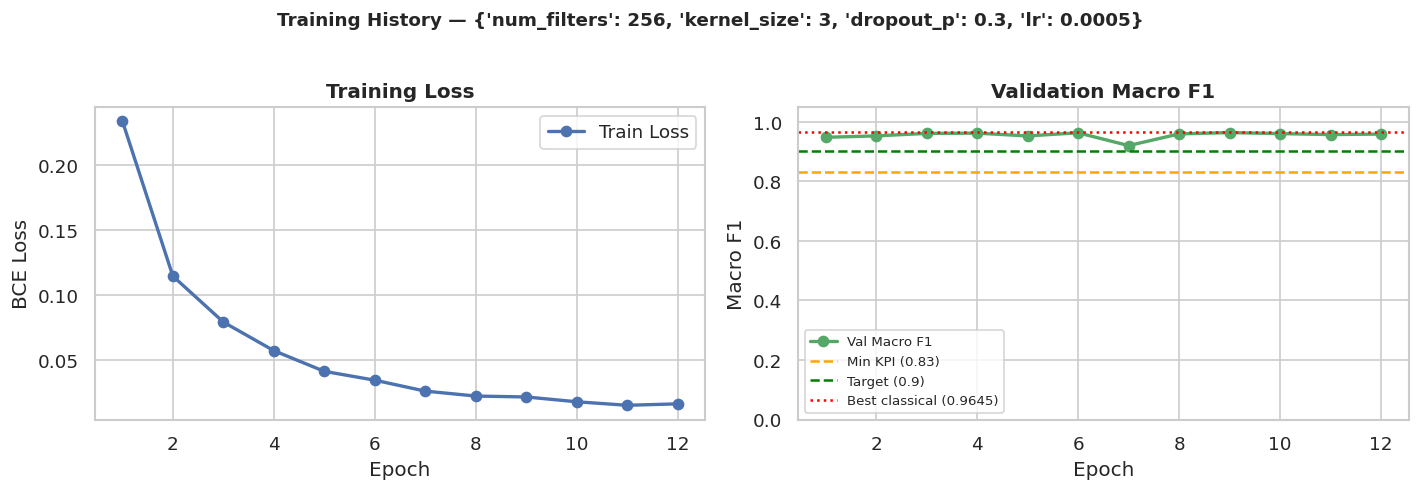

Saved: /content/drive/MyDrive/Team_project/project/fig_cnn_training_history.png


In [12]:
# ── 7a: Training history ──────────────────────────────────────────────────────
history_df = pd.DataFrame(best_overall_hist)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df['epoch'], history_df['train_loss'],
             marker='o', color='#4C72B0', lw=2, label='Train Loss')
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend()

axes[1].plot(history_df['epoch'], history_df['val_f1'],
             marker='o', color='#55A868', lw=2, label='Val Macro F1')
axes[1].axhline(KPI_MIN_F1,    color='orange', linestyle='--', lw=1.5,
                label=f'Min KPI ({KPI_MIN_F1})')
axes[1].axhline(KPI_TARGET_F1, color='green',  linestyle='--', lw=1.5,
                label=f'Target ({KPI_TARGET_F1})')
axes[1].axhline(BEST_CLASSICAL_F1, color='red', linestyle=':',  lw=1.5,
                label=f'Best classical ({BEST_CLASSICAL_F1})')
axes[1].set_title('Validation Macro F1', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Macro F1')
axes[1].set_ylim(0, 1.05); axes[1].legend(fontsize=8)

plt.suptitle(f'Training History — {best_overall_cfg}',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
fname = os.path.join(DATA_DIR, 'fig_cnn_training_history.png')
plt.savefig(fname, bbox_inches='tight'); plt.show()
print(f"Saved: {fname}")

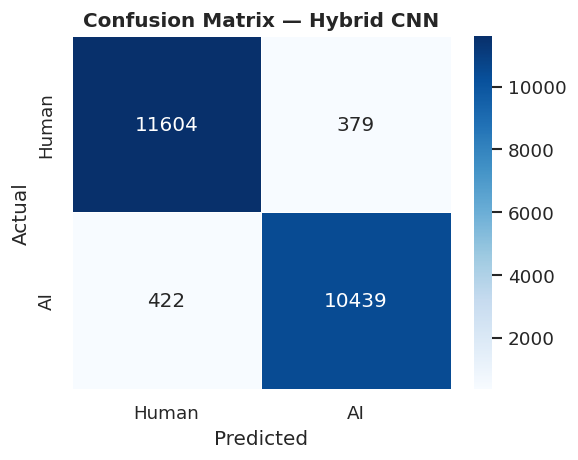

Saved: /content/drive/MyDrive/Team_project/project/fig_cm_hybrid_cnn.png


In [13]:
# ── 7b: Confusion matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(cnn_test_results['y_true'], cnn_test_results['y_pred'])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Human', 'AI'],
            yticklabels=['Human', 'AI'],
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Hybrid CNN', fontsize=12, fontweight='bold')
plt.tight_layout()
fname = os.path.join(DATA_DIR, 'fig_cm_hybrid_cnn.png')
plt.savefig(fname, bbox_inches='tight'); plt.show()
print(f"Saved: {fname}")

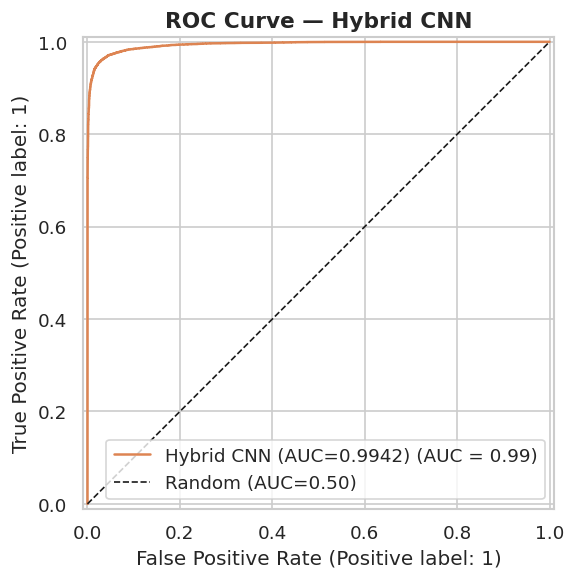

Saved: /content/drive/MyDrive/Team_project/project/fig_roc_cnn.png


In [14]:
# ── 7c: ROC curve ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    cnn_test_results['y_true'],
    cnn_test_results['y_score'],
    name=f'Hybrid CNN (AUC={cnn_test_results["roc_auc"]:.4f})',
    color='#DD8452', ax=ax
)
ax.plot([0,1],[0,1],'k--', lw=1, label='Random (AUC=0.50)')
ax.set_title('ROC Curve — Hybrid CNN', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
fname = os.path.join(DATA_DIR, 'fig_roc_cnn.png')
plt.savefig(fname, bbox_inches='tight'); plt.show()
print(f"Saved: {fname}")

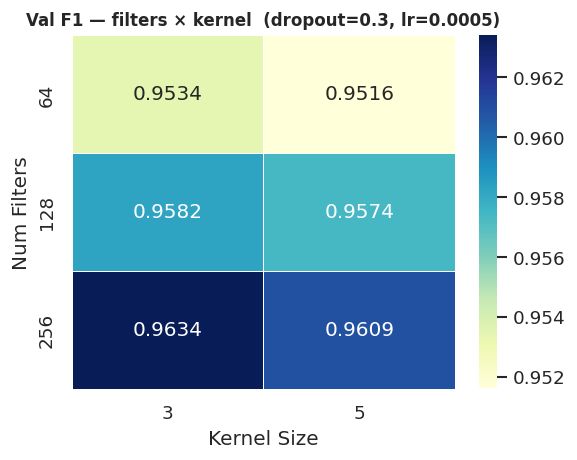

Saved: /content/drive/MyDrive/Team_project/project/fig_cnn_hp_heatmap.png


In [15]:
# ── 7d: HP tuning heatmap — best dropout + lr slice ──────────────────────────
best_dp = best_overall_cfg['dropout_p']
best_lr = best_overall_cfg['lr']
subset  = tuning_df[
    (tuning_df['dropout_p'] == best_dp) &
    (tuning_df['lr']        == best_lr)
]

if len(subset) >= 4:
    pivot = subset.pivot(index='num_filters',
                         columns='kernel_size',
                         values='val_f1')
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu',
                linewidths=0.5, ax=ax)
    ax.set_title(
        f'Val F1 — filters × kernel  (dropout={best_dp}, lr={best_lr})',
        fontsize=10, fontweight='bold'
    )
    ax.set_xlabel('Kernel Size'); ax.set_ylabel('Num Filters')
    plt.tight_layout()
    fname = os.path.join(DATA_DIR, 'fig_cnn_hp_heatmap.png')
    plt.savefig(fname, bbox_inches='tight'); plt.show()
    print(f"Saved: {fname}")
else:
    print("Not enough configs for heatmap (expected in QUICK_TEST mode).")

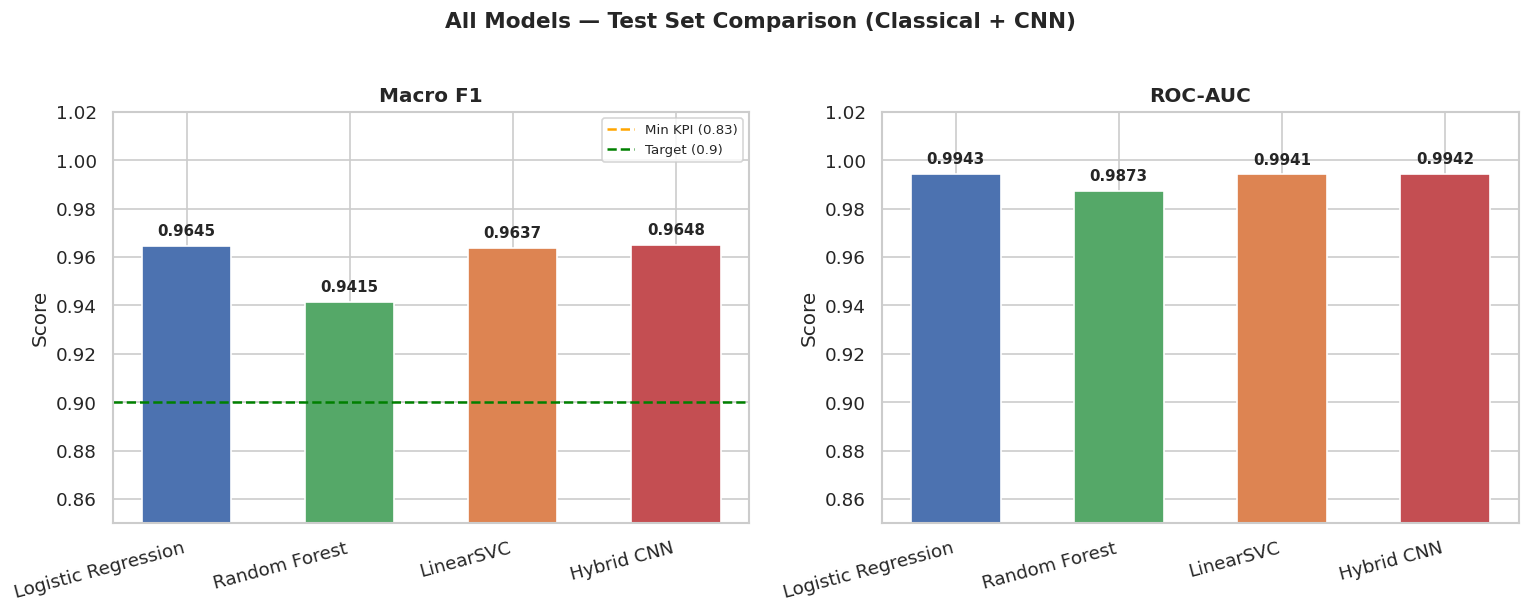

Saved: /content/drive/MyDrive/Team_project/project/fig_all_models_comparison.png


In [16]:
# ── 7e: All models comparison bar chart (classical + CNN) ─────────────────────
all_results = {
    'Logistic Regression': {'f1_macro': 0.9645, 'roc_auc': 0.9943},
    'Random Forest'      : {'f1_macro': 0.9415, 'roc_auc': 0.9873},
    'LinearSVC'          : {'f1_macro': 0.9637, 'roc_auc': 0.9941},
    'Hybrid CNN'         : {'f1_macro': cnn_test_results['f1_macro'],
                            'roc_auc': cnn_test_results['roc_auc']},
}

model_names = list(all_results.keys())
colours     = ['#4C72B0', '#55A868', '#DD8452', '#C44E52']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric, label in zip(
    axes,
    ['f1_macro', 'roc_auc'],
    ['Macro F1', 'ROC-AUC']
):
    vals = [all_results[m][metric] for m in model_names]
    bars = ax.bar(model_names, vals, color=colours, edgecolor='white', width=0.55)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{v:.4f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')
    if metric == 'f1_macro':
        ax.axhline(KPI_MIN_F1,    color='orange', linestyle='--',
                   lw=1.5, label=f'Min KPI ({KPI_MIN_F1})')
        ax.axhline(KPI_TARGET_F1, color='green',  linestyle='--',
                   lw=1.5, label=f'Target ({KPI_TARGET_F1})')
        ax.legend(fontsize=8)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_ylim(0.85, 1.02)
    ax.set_xticklabels(model_names, rotation=15, ha='right')
    ax.set_ylabel('Score')

plt.suptitle('All Models — Test Set Comparison (Classical + CNN)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
fname = os.path.join(DATA_DIR, 'fig_all_models_comparison.png')
plt.savefig(fname, bbox_inches='tight'); plt.show()
print(f"Saved: {fname}")

---
## 8. Cross-Dataset Generalisation Test

Evaluates the CNN separately on HC3 and DAIGT rows in the test split.

**File 04 cross-dataset results (confirmed):**
| Model | HC3 F1 | DAIGT F1 |
|---|---|---|
| Logistic Regression | 0.9591 | 0.9633 |
| LinearSVC | 0.9588 | 0.9619 |
| Random Forest | 0.9266 | 0.9445 |

CNN must meet the same KPI: cross-dataset Macro F1 ≥ 0.75 (min) / ≥ 0.85 (target)

In [17]:
print("\n" + "=" * 60)
print("STEP 8: Cross-dataset generalisation test")
print("=" * 60)

print("  Datasets in test split:")
print(test_df['dataset'].value_counts().to_string())
print()

cross_rows = []

for dataset_name in test_df['dataset'].unique():
    # .values → numpy bool array — avoids pandas index alignment issues
    mask   = (test_df['dataset'] == dataset_name).values
    X_seq  = X_test_glove[mask]
    X_sty  = X_test_style[mask]
    y_sub  = y_test[mask]

    if len(y_sub) == 0:
        print(f"  [SKIP] {dataset_name} — no rows in test split")
        continue

    sub_dataset = AITextDataset(X_seq, X_sty, y_sub)
    sub_loader  = DataLoader(sub_dataset, batch_size=BATCH_SIZE,
                             shuffle=False, num_workers=0)

    y_true, y_pred, y_score = evaluate_loader(
        best_overall_model, sub_loader, DEVICE
    )

    unique_classes = np.unique(y_true)
    if len(unique_classes) < 2:
        print(f"  [{dataset_name}] Only one class present — "
              f"Macro F1 not meaningful, skipping metric")
        continue

    f1  = f1_score(y_true, y_pred, average='macro')
    acc = accuracy_score(y_true, y_pred)
    kpi = '✓' if f1 >= KPI_MIN_CROSS else '✗ below min KPI'

    print(f"  {dataset_name} ({len(y_true):,} samples)")
    print(f"    Hybrid CNN   Acc={acc:.4f}   Macro F1={f1:.4f}   {kpi}")
    cross_rows.append({
        'Dataset': dataset_name, 'Model': 'Hybrid CNN',
        'Accuracy': round(acc, 4), 'Macro F1': round(f1, 4)
    })

cross_cnn_df = pd.DataFrame(cross_rows)
out = os.path.join(DATA_DIR, 'cross_dataset_cnn_results.csv')
cross_cnn_df.to_csv(out, index=False)
print(f"\nSaved: {out}")


STEP 8: Cross-dataset generalisation test
  Datasets in test split:
dataset
HC3      11946
DAIGT    10898

  HC3 (11,946 samples)
    Hybrid CNN   Acc=0.9730   Macro F1=0.9697   ✓
  DAIGT (10,898 samples)
    Hybrid CNN   Acc=0.9561   Macro F1=0.9531   ✓

Saved: /content/drive/MyDrive/Team_project/project/cross_dataset_cnn_results.csv


---
## 9. Save Best Model

In [18]:
print("\n" + "=" * 60)
print("STEP 9: Saving best Hybrid CNN checkpoint")
print("=" * 60)

# Save full checkpoint — config + weights + normalisation stats
# so the model can be fully reconstructed in app.py or the eval notebook
checkpoint = {
    'model_state_dict' : best_overall_model.state_dict(),
    'config'           : best_overall_cfg,
    'vocab_size'       : VOCAB_SIZE,
    'embed_dim'        : EMBED_DIM,
    'max_seq_len'      : MAX_SEQ_LEN,
    'num_style_feat'   : NUM_STYLE_FEAT,
    'style_mean'       : style_mean.tolist(),   # needed to normalise at inference
    'style_std'        : style_std.tolist(),    # needed to normalise at inference
    'val_f1'           : best_overall_f1,
    'test_f1'          : cnn_test_results['f1_macro'],
    'test_roc_auc'     : cnn_test_results['roc_auc'],
    'test_accuracy'    : cnn_test_results['accuracy'],
}

ckpt_path = os.path.join(DATA_DIR, 'model_cnn.pt')
torch.save(checkpoint, ckpt_path)
print(f"  Saved: {ckpt_path}")
print()
print("  To reload in app.py or evaluation notebook:")
print("    ckpt  = torch.load('model_cnn.pt', map_location='cpu')")
print("    model = HybridCNN(embedding_matrix, **ckpt['config'])")
print("    model.load_state_dict(ckpt['model_state_dict'])")
print("    model.eval()")


STEP 9: Saving best Hybrid CNN checkpoint
  Saved: /content/drive/MyDrive/Team_project/project/model_cnn.pt

  To reload in app.py or evaluation notebook:
    ckpt  = torch.load('model_cnn.pt', map_location='cpu')
    model = HybridCNN(embedding_matrix, **ckpt['config'])
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()


---
## 10. Final Summary

In [19]:
print("\n" + "=" * 60)
print("HYBRID CNN — FINAL SUMMARY")
print("=" * 60)
print()
print(f"  Best hyperparameters : {best_overall_cfg}")
print(f"  Best val Macro F1    : {best_overall_f1:.4f}")
print()
f1  = cnn_test_results['f1_macro']
roc = cnn_test_results['roc_auc']
acc = cnn_test_results['accuracy']
print("  Test set results:")
print(f"    Accuracy    : {acc:.4f}")
print(f"    Macro F1    : {f1:.4f}")
print(f"    ROC-AUC     : {roc:.4f}")
print()
print("  KPI check:")
print(f"    Min KPI  (>= {KPI_MIN_F1})  : {'✓ Pass' if f1 >= KPI_MIN_F1    else '✗ Fail'}")
print(f"    Target   (>= {KPI_TARGET_F1})  : {'✓ Pass' if f1 >= KPI_TARGET_F1 else '— Not yet'}")
print(f"    vs LR    ({BEST_CLASSICAL_F1})  : "
      f"{'✓ beats' if f1 >= BEST_CLASSICAL_F1 else f'— below ({f1:.4f} vs {BEST_CLASSICAL_F1})'}")
print()
print("  Files saved:")
saved = [
    'model_cnn.pt',
    'cnn_tuning_results.csv',
    'cross_dataset_cnn_results.csv',
    'fig_cnn_training_history.png',
    'fig_cm_hybrid_cnn.png',
    'fig_roc_cnn.png',
    'fig_cnn_hp_heatmap.png',
    'fig_all_models_comparison.png',
]
for f in saved:
    print(f"    {f}")
print()
print("  Next step:")
print("    -> 06_roberta_finetuning.ipynb")
print("       Run on Google Colab (GPU required)")
print("       Loads: roberta_train/val/test _ids/_mask/_labels .npy")
print()
print("=" * 60)


HYBRID CNN — FINAL SUMMARY

  Best hyperparameters : {'num_filters': 256, 'kernel_size': 3, 'dropout_p': 0.3, 'lr': 0.0005}
  Best val Macro F1    : 0.9634

  Test set results:
    Accuracy    : 0.9649
    Macro F1    : 0.9648
    ROC-AUC     : 0.9942

  KPI check:
    Min KPI  (>= 0.83)  : ✓ Pass
    Target   (>= 0.9)  : ✓ Pass
    vs LR    (0.9645)  : ✓ beats

  Files saved:
    model_cnn.pt
    cnn_tuning_results.csv
    cross_dataset_cnn_results.csv
    fig_cnn_training_history.png
    fig_cm_hybrid_cnn.png
    fig_roc_cnn.png
    fig_cnn_hp_heatmap.png
    fig_all_models_comparison.png

  Next step:
    -> 06_roberta_finetuning.ipynb
       Run on Google Colab (GPU required)
       Loads: roberta_train/val/test _ids/_mask/_labels .npy

